**SVM and Naive Bayes models on Balanced data **

This notebook presents SVM and Naive Bayes models on balanced dataset.To ensure uniformity, as this is a comparative analysis study,the same data preprocessing and preparation techniques are applied.

In [ ]:
#importing the necessary libraries
import pandas as pd
from nltk.tokenize import word_tokenize
import nltk
import re
from nltk.corpus import stopwords
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

 Data loading, Cleaning, Tokenizing,Label Encoding, and Class Balancing

**Data cleaning**

This step involves removing  non-alphabetic characters, Converting text to lowercase and removing stop words,Tokenizing and encoding  topic group   into numeric format for prepration for the models.


**Balancing the Dataset with Undersampling and Oversampling .**

A target size 5,000 is set basing on the median, and undersampling is done for classes that exceed 5,000 by randomly selecting and removing the samples until the target is reached. For classes with less than 5,000, oversampling is done by randomly duplicating samples until there are 5,000 thus achieving a balanced dataset.



In [ ]:

# Loading the dataset
data = pd.read_csv('Service_tickets.csv')

# Getting count of classes
class_counts = data['Topic_group'].value_counts()
print(class_counts)

# Cleaning the text data
def clean_text(text):
    stop_words = set(stopwords.words('english'))
    text = text.lower()  # Convert text to lowercase
    text = re.sub('[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
    tokens = word_tokenize(text)  # Tokenize using word_tokenize
    tokens = [word for word in tokens if word not in stop_words]  # Remove stop words
    return ' '.join(tokens)  # Rejoin tokens into a single string

data['Cleaned_Document'] = data['Document'].apply(clean_text)

# Defining the dataframe after cleaning
data = data[['Cleaned_Document', 'Topic_group']]

# Encoding category labels using category codes
data["encoded_label"] = data["Topic_group"].astype('category').cat.codes

# Undersample and oversample the dataset to target 5000 instances per class
target_size = 5000
balanced_data = pd.DataFrame(columns=data.columns)
for topic_group in data['Topic_group'].unique():
    topic_group_data = data[data['Topic_group'] == topic_group]
    if len(topic_group_data) > target_size:
        # Undersample
        undersampled_data = resample(topic_group_data, replace=False, n_samples=target_size, random_state=42)
        balanced_data = pd.concat([balanced_data, undersampled_data])
    else:
        # Oversample
        oversampled_data = resample(topic_group_data, replace=True, n_samples=target_size, random_state=42)
        balanced_data = pd.concat([balanced_data, oversampled_data])

balanced_data.reset_index(drop=True, inplace=True)

# Print class distribution after balancing
print("Class distribution after balancing:")
print(balanced_data['Topic_group'].value_counts())




Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64
Class distribution after balancing:
Topic_group
Hardware                 5000
Access                   5000
Miscellaneous            5000
HR Support               5000
Purchase                 5000
Administrative rights    5000
Storage                  5000
Internal Project         5000
Name: count, dtype: int64


**Data Splitting and TF-IDF Vectorization * *

The Balanced Data is split into Training and Test Sets using stratified spliting to ensure the class distribution in the training and test sets represents the overall class distribution in the balanced dataset.

TF-IDF vectorization to convert the text data into numerical feature vectors, focusing on the 5,060 most important words which is based on the maximum vocabulary size

In [ ]:
# Splitting the data into training (80%) and test (20%) sets
train_data, test_data = train_test_split(balanced_data, test_size=0.2, stratify=balanced_data['Topic_group'], random_state=42)

X_train = train_data['Cleaned_Document']
X_test = test_data['Cleaned_Document']
y_train = train_data['encoded_label']
y_test = test_data['encoded_label']

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5060)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Model Training and Evaluation Using Support Vector Machine (SVM) and Naive Bayes
 and Calculating performance metrics: accuracy, F1 score, precision, and recall  and printing a detailed classification report to provide insights into how well the model performs across different classes

In [ ]:
# Converting y_train and y_test to integers after balancing
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Support Vector Machine (SVM)
svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
print("Support Vector Machine (SVM) Classification Report:\n", classification_report(y_test, y_pred_svm))

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_pred_nb))

Support Vector Machine (SVM) Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.88      0.90      1000
           1       0.92      0.97      0.94      1000
           2       0.82      0.82      0.82      1000
           3       0.79      0.75      0.77      1000
           4       0.95      0.96      0.95      1000
           5       0.83      0.82      0.83      1000
           6       0.97      0.96      0.97      1000
           7       0.94      0.98      0.96      1000

    accuracy                           0.89      8000
   macro avg       0.89      0.89      0.89      8000
weighted avg       0.89      0.89      0.89      8000

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82      1000
           1       0.79      0.92      0.85      1000
           2       0.79      0.70      0.74      1000
           3       0.76      0.61      0.68



**Confusion matrix**

Generated to visualize and understand the performance of model in more detail and see number of correct and incorrect predictions for each class to idenfity misclassification and evaluate how well the  model handles each class.

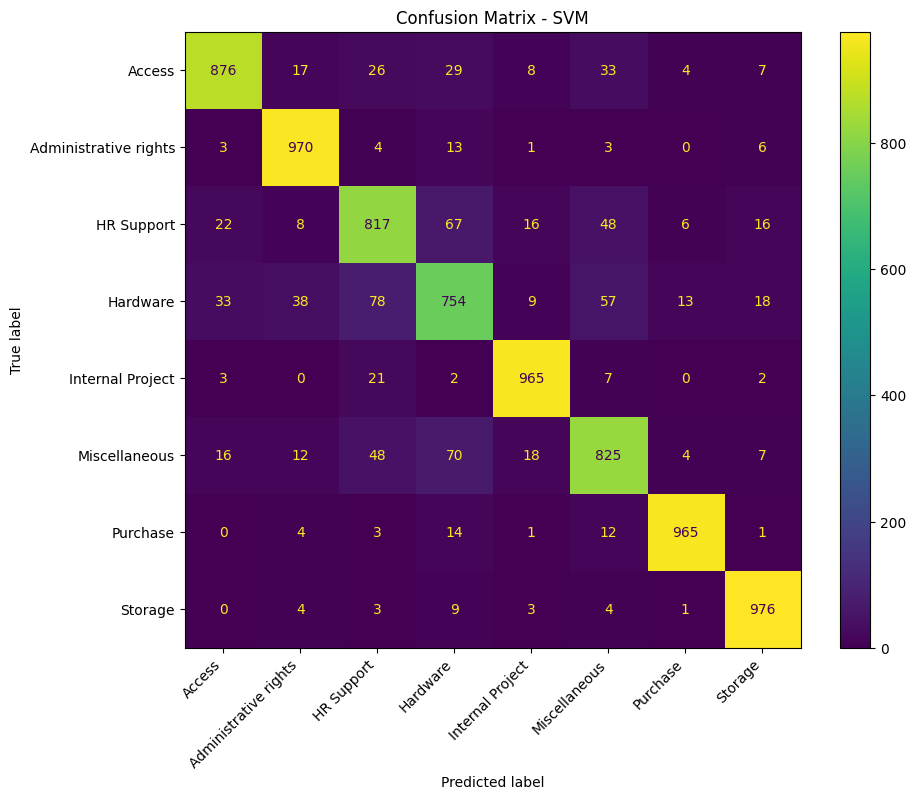

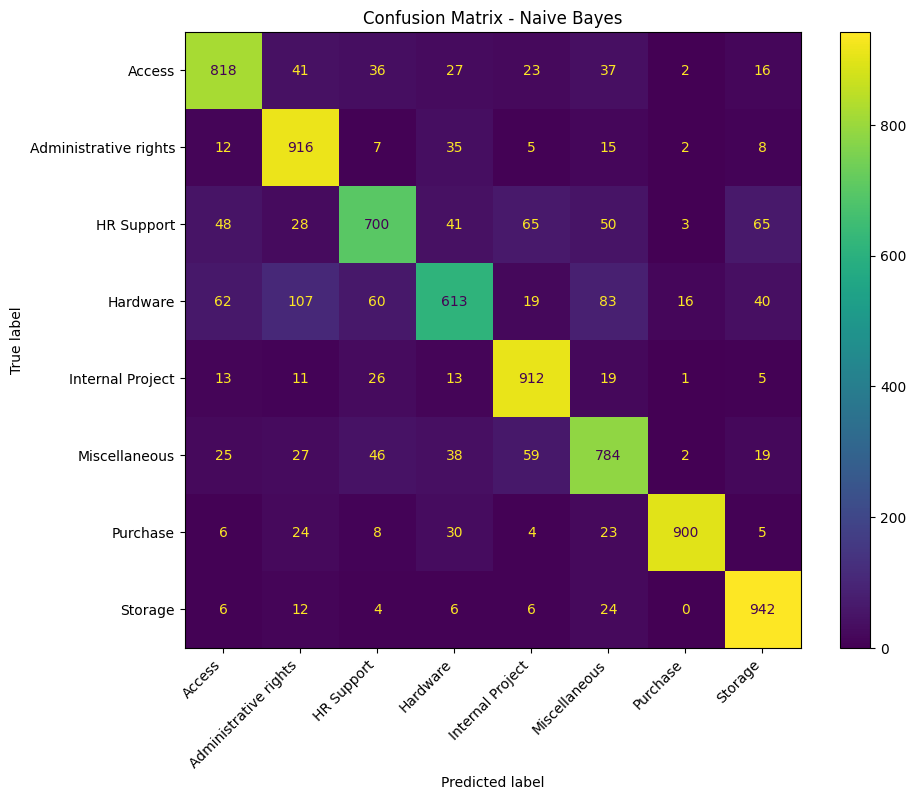

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Calculate and plot the confusion matrix for SVM
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_svm,
                                  display_labels=data["Topic_group"].astype('category').cat.categories)
plt.figure(figsize=(10, 8))
disp_svm.plot(cmap='viridis', ax=plt.gca())
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix - SVM')
plt.show()

# Calculate and plot the confusion matrix for Naive Bayes
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_nb,
                                 display_labels=data["Topic_group"].astype('category').cat.categories)
plt.figure(figsize=(10, 8))
disp_nb.plot(cmap='viridis', ax=plt.gca())
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()
